#  Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw_listings.csv')

In [2]:
df.sample(10)

,name,url,price,mileage,location
2913,"Lexus Is 250 2006, 197K Miles",https://www.craigslist.org/view/d/dublin-lexus...,6400,197000.0,dublin / pleasanton / livermore
2092,2020 Cadillac Escalade Esv Platinum. 1 Owner. ...,https://www.craigslist.org/view/d/concord-2020...,36999,80000.0,concord/pleasanthill/martinez
2832,]2001 Toyota Mr2 Spyder,https://www.craigslist.org/view/d/san-rafael-2...,8500,145000.0,san rafael
1845,1992 Mazda Miata - Sunburst Yellow 5 Speed,https://www.craigslist.org/view/d/pleasanton-1...,11900,160000.0,Pleasanton
3972,1991 Toyota 4Runner,https://www.craigslist.org/view/d/morgan-hill-...,3600,276000.0,morgan hill
3856,01 Mazda Mx-5 Miata,https://www.craigslist.org/view/d/fremont-01-m...,8150,99000.0,fremont
1645,2017 Toyota Avalon Touring,https://www.craigslist.org/view/d/san-jose-201...,12900,120000.0,sanjosesouth
2727,Jaguar 2017 Xf Diesel 2.0,https://www.craigslist.org/view/d/pleasanton-j...,13000,37000.0,dublin / pleasanton / livermore
513,Bmw 330I 2017,https://www.craigslist.org/view/d/dublin-bmw-3...,17800,86000.0,dublin/pleasanton/livermore
763,Clean 2017 Nissan Altima 2.5L,https://www.craigslist.org/view/d/san-jose-cle...,9900,67000.0,sanjoseeast


In [3]:
df.describe()

,price,mileage
count,4322.000000,4.319000e+03
mean,12614.401435,1.293615e+05
std,22685.557309,9.365913e+04
min,1.000000,1.000000e+00
25%,4500.000000,7.900000e+04
50%,8000.000000,1.220000e+05
75%,14900.000000,1.700000e+05
max,900000.000000,2.020000e+06


# EDA & Data Cleaning

### Feature Cleaning: Location

In [4]:
df['location'] = df['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

In [5]:
df.sample(10)

,name,url,price,mileage,location
2867,Mazda 3 S Touring 2008,https://www.craigslist.org/view/d/aptos-mazda-...,4500,150000.0,aptos
3617,"Lincoln Navigator L (Full Size Suv, 8 Passenger)",https://www.craigslist.org/view/d/pleasanton-l...,5900,338000.0,alameda
39,"2006 Toyota Sienna Le For Sale 278K, Not Runni...",https://www.craigslist.org/view/d/concord-2006...,1450,279000.0,concord
443,2015 Lexus Rc350Fsport,https://www.craigslist.org/view/d/pleasant-hil...,12999,121000.0,pleasanthill
218,"2015 Mazda Cx5 Touring, 95K Low Mileage",https://www.craigslist.org/view/d/hayward-2015...,11900,96000.0,hayward
328,"2010 Toyota Corolla Le ""Clean Title""",https://www.craigslist.org/view/d/hayward-2010...,4500,208000.0,hayward
2073,2016 Ford F-350 Super Duty Lariat Fx4 Package ...,https://www.craigslist.org/view/d/talmage-2016...,30000,123000.0,mendocinocounty
4159,2019 Kia Optima Lx,https://www.craigslist.org/view/d/sunnyvale-20...,7900,155000.0,sunnyvale
2590,2011 Toyota Camry Le Only 20K Miles One Owner ...,https://www.craigslist.org/view/d/burlingame-2...,12500,21000.0,burlingame
689,1999 Gmc Suburban 4X4,https://www.craigslist.org/view/d/san-leandro-...,3650,5000.0,sanleandro


### Univariate Analysis & Outliers

In [6]:
print(df[['price', 'mileage']].describe())

               price       mileage
count    4322.000000  4.319000e+03
mean    12614.401435  1.293615e+05
std     22685.557309  9.365913e+04
min         1.000000  1.000000e+00
25%      4500.000000  7.900000e+04
50%      8000.000000  1.220000e+05
75%     14900.000000  1.700000e+05
max    900000.000000  2.020000e+06


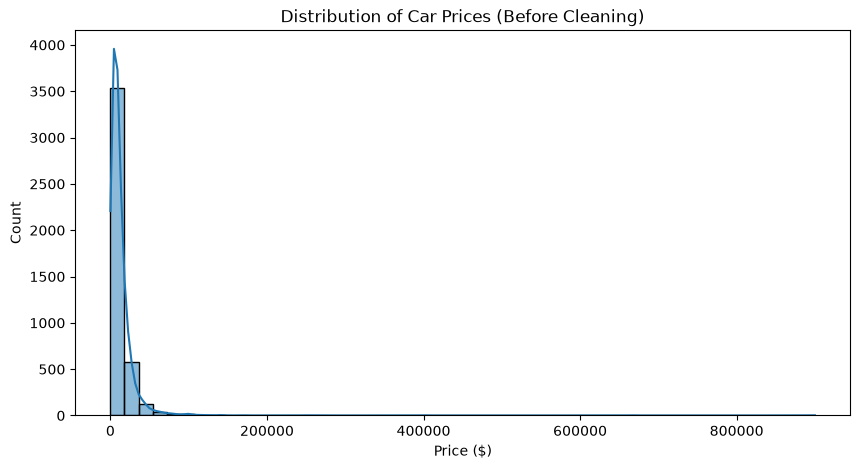

In [7]:
# Plot price distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Before Cleaning)')
plt.xlabel('Price ($)')
plt.show()

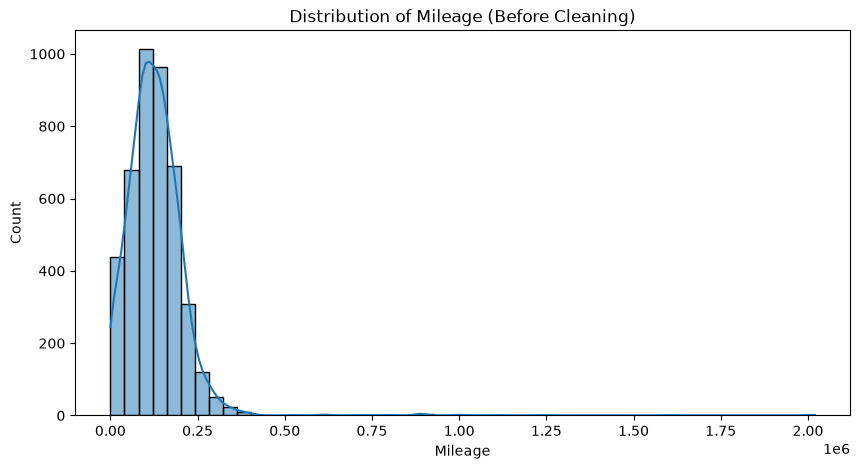

In [8]:
# Plot Mileage distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (Before Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [9]:
# 1. Define the realistic bounds for vehicles
MIN_PRICE = 800
MAX_PRICE = 100000
MIN_MILEAGE = 100
MAX_MILEAGE = 300000

# 2. Filter the DataFrame
df_clean = df[
    (df['price'] >= MIN_PRICE) & 
    (df['price'] <= MAX_PRICE) &
    (df['mileage'] >= MIN_MILEAGE) & 
    (df['mileage'] <= MAX_MILEAGE)
].copy()

# Drop any remaining rows where mileage or price might be NaN
df_clean = df_clean.dropna(subset=['price', 'mileage'])

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_clean)}")

# New mathematical summary
print(df_clean[['price', 'mileage']].describe())

Rows before trimming: 4322
Rows after trimming: 4121
               price        mileage
count    4121.000000    4121.000000
mean    12017.065518  123797.778452
std     11860.151062   62596.747567
min       800.000000     100.000000
25%      4700.000000   80000.000000
50%      8300.000000  122000.000000
75%     14999.000000  167000.000000
max    100000.000000  300000.000000


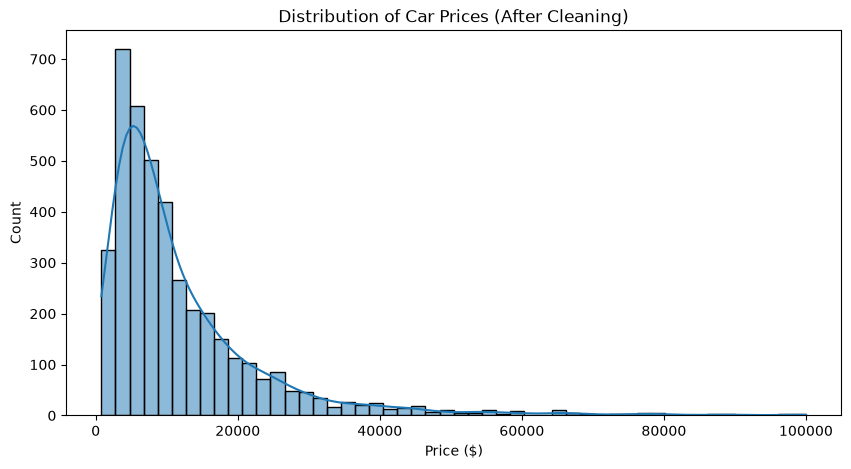

In [10]:
# Plot price distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (After Cleaning)')
plt.xlabel('Price ($)')
plt.show()

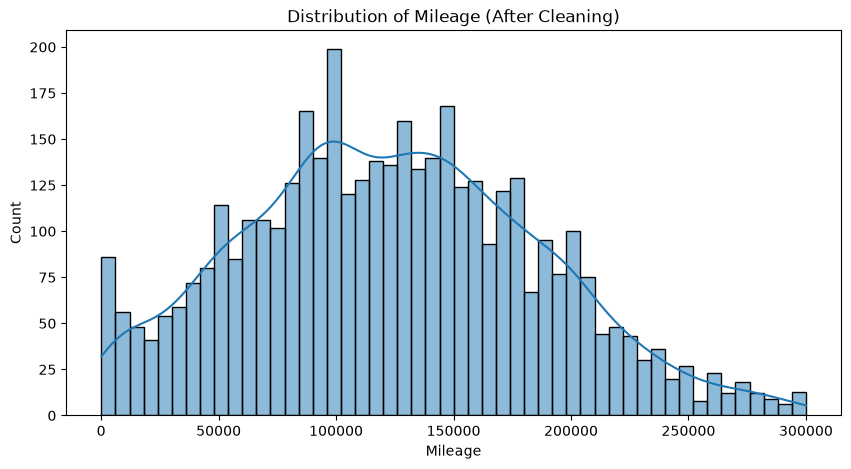

In [11]:
# Plot Mileage distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (After Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [12]:
# 1. Define a list of common car manufacturers
manufacturers = [
    'Toyota', 'Honda', 'Ford', 'Chevrolet', 'Chevy', 'Nissan', 'BMW', 'Mercedes', 'Benz', 
    'Audi', 'Lexus', 'Subaru', 'Volkswagen', 'Vw', 'Hyundai', 'Kia', 'Mazda', 'Acura', 'Jeep', 
    'Dodge', 'Ram', 'GMC', 'Cadillac', 'Infiniti', 'Volvo', 'Mitsubishi', 'Mini',
    'Porsche', 'Tesla', 'Land Rover', 'Jaguar', 'Chrysler', 'Buick', 'Pontiac', 'Saturn'
]

In [13]:
def extract_make(title):
    # Lowercase the title to make matching case-insensitive
    title_lower = title.lower()
    
    # Loop through our list of manufacturers
    for make in manufacturers:
        # Check if the lowercased make is in the title
        if make.lower() in title_lower:
            return make.title() # Return it nicely formatted (e.g., "Honda")
            
    return None # If no manufacturer is found, return None

In [14]:
# 2. Apply the function to our 'name' column
df_clean['make'] = df_clean['name'].apply(extract_make)

print("Makes found:")
print(df_clean['make'].value_counts())

print("\nRows with missing Make:")
print(df_clean['make'].isnull().sum())

Makes found:
make
Toyota        588
Ford          447
Honda         347
Mercedes      204
Bmw           201
Nissan        176
Chevrolet     151
Lexus         135
Chevy         129
Subaru        126
Dodge         100
Jeep           96
Acura          85
Audi           80
Volkswagen     77
Hyundai        71
Gmc            62
Mazda          60
Vw             56
Mini           56
Kia            55
Ram            48
Volvo          38
Porsche        37
Chrysler       32
Tesla          31
Pontiac        27
Cadillac       26
Jaguar         23
Infiniti       22
Land Rover     20
Buick          19
Mitsubishi     15
Saturn          7
Benz            5
Name: count, dtype: int64

Rows with missing Make:
469


In [15]:
# Look at the ones it couldn't find to see if we missed any brands
missing_makes = df_clean[df_clean['make'].isnull()]
print("\nSample titles with missing makes:")
print(missing_makes['name'])


Sample titles with missing makes:
5       2019 Range Rover Sport Hse, Engine Disassemble...
6                                               Hummer H3
25                  2008 Mercury Grand Marquis Ls - $5800
42                                2007 Nissam Frontier Xe
46                                     1967 Citroen Diane
                              ...                        
4287    Sprinter 4X4 Camper - Light Build - Top Tear Gear
4294                             1922 Model Tt Depot Hack
4295                         Taylor/Dunn 36V Utility Cart
4308                              1974 Rallye Charger 440
4312                                   2001 Golf Gls 1.8T
Name: name, Length: 469, dtype: str


In [16]:
# Drop rows where we still couldn't find the make
df_clean = df_clean.dropna(subset=['make'])

print(f"Final clean dataset size: {len(df_clean)} rows")

Final clean dataset size: 3652 rows


In [17]:
df_clean

,name,url,price,mileage,location,make
0,2015 Buick Regal Premium Ii Turbo - Only 52K M...,https://www.craigslist.org/view/d/san-bruno-20...,9975,52000.0,sanbruno,Buick
1,2012 Vw Gti,https://www.craigslist.org/view/d/watsonville-...,6000,150000.0,watsonville,Vw
2,Volvo,https://www.craigslist.org/view/d/forestville-...,21500,78000.0,russianriver,Volvo
3,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi
4,Modified 2011 Toyota Tacoma Trd Sport Double Cab,https://www.craigslist.org/view/d/san-rafael-m...,25000,98000.0,sanrafael,Toyota
...,...,...,...,...,...,...
4317,Truck Ford F450,https://www.craigslist.org/view/d/walnut-creek...,4000,170000.0,walnut creek,Ford
4318,Blue 2010 Toyota Prius 4. 116K Low Miles! 52 M...,https://www.craigslist.org/view/d/petaluma-blu...,5900,116000.0,petaluma,Toyota
4319,2002 Cummins 5.9 Liter Crashed Ram Truck Good ...,https://www.craigslist.org/view/d/hollister-20...,2500,167000.0,san jose downtown,Ram
4320,2013 Jeep Wrangler Sahara 9400 Miles,https://www.craigslist.org/view/d/santa-rosa-2...,29990,9405.0,santa rosa,Jeep


In [ ]:
# 1. Define a dictionary mapping Makes to their most popular models
car_models_dict = {
    'Toyota': ['Camry', 'Corolla', 'Prius', 'Sienna', 'Tacoma', 'Tundra', 'Rav4', 'Highlander', '4Runner', 'Avalon', 'Yaris', 'Sequoia', 'Matrix', 'Fj Cruiser', 'Venza', 'Mirai', 'C-Hr', 'C-HR', 'Supra', 'Land Cruiser', 'Celica', 'MR2', 'Echo', 'Solara', 'Paseo', 'Previa', 'MR2 Spyder', 'Tercel', 'Camry Solara', 'Cressida', 'Venza', 'Corolla Hatchback', 'Corolla Cross', 'Corolla Hybrid', 'Camry Hybrid', 'Rav4 Hybrid', 'Highlander Hybrid', 'Sienna Hybrid', 'Tacoma TRD', 'Tundra TRD',],
    'Honda': ['Civic', 'Accord', 'Cr-v', 'Crv', 'Odyssey', 'Pilot', 'Fit', 'Hr-v', 'Hrv', 'Element', 'Ridgeline', 'Insight', 'Passport', 'S2000', 'Prelude', 'Clarity', 'Crosstour', 'Del Sol', 'S2000', 'CR-Z', 'NSX', 'Integra', 'Vigor', 'Ascot', 'Civic Si', 'Accord Hybrid', 'CR-V Hybrid', 'Insight Hybrid', 'Clarity Plug-in', 'Clarity Electric', 'Fit EV', 'HR-V Sport', 'Ridgeline Black Edition', 'Odyssey Elite', 'Pilot Black Edition', 'Civic Type R', 'Accord Sport', 'CR-V Touring', 'HR-V EX-L', 'Fit Sport', 'Ridgeline RTL-E', 'Odyssey Touring', 'Pilot Touring'],
    'Ford': ['F150', 'F-150', 'F250', 'F-250', 'F350', 'F-350', 'Escape', 'Explorer', 'Focus', 'Fusion', 'Mustang', 'Edge', 'Transit', 'Ranger', 'Expedition', 'Taurus', 'Bronco', 'Flex', 'EcoSport', 'C-Max', 'Fiesta', 'GT', 'Lightning', 'Maverick', 'Thunderbird', 'Econoline', 'Excursion', 'Windstar', 'Probe', 'Tempo', 'Aspire', 'Contour', 'Escape Hybrid', 'Fusion Hybrid', 'C-Max Hybrid', 'Transit Connect', 'Transit Connect Wagon', 'Transit Connect Van', 'Transit Connect Cargo', 'Transit Connect Passenger', 'Transit Connect XL', 'Transit Connect XLT', 'Transit Connect Titanium', 'Transit Connect Limited', 'Transit Connect Sport', 'Transit Connect SE', 'Transit Connect SEL', 'Transit Connect LWB', 'Transit Connect SWB'],
    'Chevrolet': ['Silverado', 'Equinox', 'Malibu', 'Cruze', 'Tahoe', 'Impala', 'Colorado', 'Camaro', 'Corvette', 'Suburban', 'Traverse', 'Spark', 'Sonic', 'Volt', 'Bolt', 'Trax', 'Blazer', 'Express', 'Avalanche', 'SSR', 'HHR', 'Cobalt', 'Caprice', 'Lumina', 'Monte Carlo', 'Uplander', 'Venture', 'Astro', 'Tracker', 'S-10', 'G-Series Van', 'G-Series Truck', 'K-Series Truck', 'R-Series Truck', 'S-10 Blazer', 'S-10 Pickup', 'C/K Series', 'Chevelle', 'Nova', 'El Camino', 'Bel Air', 'Impala SS', 'Caprice Classic', 'Monte Carlo SS', 'Camaro ZL1', 'Corvette Z06', 'Silverado HD', 'Colorado ZR2', 'Tahoe RST', 'Suburban RST'],
    'Nissan': ['Altima', 'Sentra', 'Rogue', 'Maxima', 'Murano', 'Pathfinder', 'Versa', 'Frontier', 'Titan', 'Armada', 'Leaf', '350Z', '370Z', 'Juke', 'Kicks', 'GT-R', 'Xterra', 'Cube', 'Quest', 'NV200', 'NV1500', 'NV2500', 'NV3500', 'NV Cargo', 'NV Passenger', 'NV Van', 'NV Wagon', 'NV200 Compact Cargo', 'NV200 Compact Passenger', 'NV200 Compact Van', 'NV200 Compact Wagon', 'NV200 Compact Truck', 'NV200 Compact SUV', 'NV200 Compact Crossover', 'NV200 Compact Minivan', 'NV200 Compact Pickup', 'NV200 Compact Utility', 'NV200 Compact Commercial', 'NV200 Compact Fleet', 'NV200 Compact Delivery', 'NV200 Compact Service', 'NV200 Compact Work', 'NV200 Compact Business', 'NV200 Compact Professional', 'NV200 Compact Industrial', 'NV200 Compact Construction', 'NV200 Compact Maintenance', 'NV200 Compact Repair', 'NV200 Compact Technician', 'NV200 Compact Installer', 'NV200 Compact Operator'],
    'Bmw': ['328I', '335I', '325I', 'X5', 'X3', 'M3', 'M4', 'M5', '528I', '535I', '750Li', 'X1', 'X6', 'Z4', 'I3', 'I8', 'M2', 'M6', 'X4', 'X7', '330I', '340I', '430I', '440I', '530I', '540I', '640I', '650I', '740I', '750I', '840I', '850I', 'M550I', 'M760I', 'X2', 'X5 M', 'X6 M', 'Z3', 'Z8', 'I4', 'I5', 'I6', 'I7', 'I8 Roadster', 'M1', 'M3 E30', 'M3 E36', 'M3 E46', 'M3 E92', 'M4 GTS', 'M5 E28', 'M5 E34', 'M5 E39', 'M5 E60', 'M6 E63', 'M6 E64', 'M6 F12', 'M6 F13', 'M8', 'X3 M', 'X4 M', 'X5 M50i', 'X6 M50i', 'Z4 M40i'],
    'Mercedes': ['C300', 'E350', 'E320', 'E300', 'Ml350', 'Glk350', 'S550', 'S500', 'Gle', 'Glc', 'Gla', 'Sprinter', 'C63', 'Amg', 'C230', 'C240', 'C250', 'C280', 'C320', 'C350', 'E320', 'E350', 'E500', 'E550', 'S430', 'S500', 'S550', 'S600', 'S63', 'S65', 'G550', 'G63', 'G65', 'Gla250', 'Glc300', 'Glc43', 'Gle350', 'Gle43', 'Metris', 'Sprinter 2500', 'Sprinter 3500', 'Sprinter 2500 Cargo', 'Sprinter 3500 Cargo', 'Sprinter 2500 Passenger', 'Sprinter 3500 Passenger', 'Sprinter 2500 Crew', 'Sprinter 3500 Crew', 'Sprinter 2500 Van', 'Sprinter 3500 Van', 'Sprinter 2500 Chassis', 'Sprinter 3500 Chassis', 'Sprinter 2500 Cab', 'Sprinter 3500 Cab'],
    'Subaru': ['Outback', 'Forester', 'Impreza', 'Legacy', 'Crosstrek', 'Wrx', 'Brz', 'Ascent', 'Tribeca', 'Baja', 'Justy', 'Alcyone', 'Vivio', 'Sambar', 'R1', 'R2', 'Exiga', 'Trezia', 'Levorg', 'WRX STI', 'WRX Premium', 'WRX Limited', 'WRX Base', 'WRX Sport', 'WRX Touring', 'WRX Series.Gray', 'WRX Series.Blue', 'WRX Series.Red', 'WRX Series.White', 'WRX Series.Black', 'WRX Series.Silver', 'WRX Series.Gold', 'WRX Series.Green', 'WRX Series.Yellow', 'WRX Series.Orange', 'WRX Series.Purple', 'WRX Series.Bronze', 'WRX Series.Copper', 'WRX Series.Platinum', 'WRX Series.Titanium', 'WRX Series.Carbon', 'WRX Series.Aluminum', 'WRX Series.Steel', 'WRX Series.Iron', 'WRX Series.Nickel', 'WRX Series.Chrome'],
    'Volkswagen': ['Jetta', 'Passat', 'Golf', 'Gti', 'Tiguan', 'Touareg', 'Atlas', 'Beetle', 'Arteon', 'CC', 'Eos', 'R32', 'Scirocco', 'Vanagon', 'Eurovan', 'Rabbit', 'Fox', 'Dasher', 'Thing', 'Karmann Ghia', 'Phaeton', 'New Beetle', 'New Beetle Convertible', 'Golf R', 'Golf Alltrack', 'Golf SportWagen', 'Golf GTI', 'Golf TDI', 'Golf R32', 'Golf R-Line', 'Golf SE', 'Golf SEL', 'Golf S', 'Golf Wolfsburg Edition', 'Golf GTI Rabbit Edition', 'Golf GTI Autobahn', 'Golf GTI Performance', 'Golf GTI S', 'Golf GTI SE', 'Golf GTI SEL', 'Golf GTI Wolfsburg Edition', 'Golf GTI Clubsport', 'Golf GTI TCR', 'Golf GTI Edition 35', 'Golf GTI Edition 30', 'Golf GTI Edition 20', 'Golf GTI Edition 10', 'Golf GTI Edition 5', 'Golf GTI Edition 1'],
    'Vw': ['Jetta', 'Passat', 'Golf', 'Gti', 'Tiguan', 'Touareg', 'Atlas', 'Beetle', 'Arteon', 'CC', 'Eos', 'R32', 'Scirocco', 'Vanagon', 'Eurovan', 'Rabbit', 'Fox', 'Dasher', 'Thing', 'Karmann Ghia', 'Phaeton', 'New Beetle', 'New Beetle Convertible', 'Golf R', 'Golf Alltrack', 'Golf SportWagen', 'Golf GTI', 'Golf TDI', 'Golf R32', 'Golf R-Line', 'Golf SE', 'Golf SEL', 'Golf S', 'Golf Wolfsburg Edition', 'Golf GTI Rabbit Edition', 'Golf GTI Autobahn', 'Golf GTI Performance', 'Golf GTI S', 'Golf GTI SE', 'Golf GTI SEL', 'Golf GTI Wolfsburg Edition', 'Golf GTI Clubsport', 'Golf GTI TCR', 'Golf GTI Edition 35', 'Golf GTI Edition 30', 'Golf GTI Edition 20', 'Golf GTI Edition 10', 'Golf GTI Edition 5', 'Golf GTI Edition 1'],
    'Lexus': ['Rx', 'Es', 'Is', 'Nx', 'Gx', 'Lx', 'Gs', 'Ls', 'Ct', 'Rc', 'Ux', 'Lfa', 'Rx Hybrid', 'Es Hybrid', 'Is F', 'Gs F', 'Ls F', 'Rc F', 'Ux Hybrid', 'Nx Hybrid', 'Gx 460', 'Gx 470', 'Lx 570', 'Rx 350', 'Rx 450h', 'Es 350', 'Es 300h', 'Is 250', 'Is 350', 'Gs 350', 'Gs 450h', 'Ls 460', 'Ls 600h', 'Rc 350', 'Rc F', 'Ux 200', 'Ux 250h'],
    'Audi': ['A4', 'A6', 'Q5', 'Q7', 'A3', 'S4', 'Tt', 'Q3', 'S5', 'S3', 'A5', 'A7', 'A8', 'Q8', 'R8', 'E-Tron', 'E-Tron Sportback', 'E-Tron GT', 'E-Tron Quattro', 'E-Tron 55', 'E-Tron 50', 'E-Tron 40', 'E-Tron 35', 'E-Tron 30', 'E-Tron 25', 'E-Tron 20', 'E-Tron 15', 'E-Tron 10'],
    'Jeep': ['Grand Cherokee', 'Wrangler', 'Cherokee', 'Compass', 'Renegade', 'Patriot', 'Gladiator', 'Commander', 'Liberty', 'Wagoneer', 'Grand Wagoneer', 'Cherokee Trailhawk', 'Cherokee Latitude', 'Cherokee Limited', 'Cherokee Overland', 'Cherokee High Altitude', 'Cherokee Altitude', 'Cherokee Sport', 'Cherokee North Edition', 'Cherokee Freedom Edition', 'Cherokee Upland Edition', 'Cherokee 80th Anniversary Edition', 'Wrangler Unlimited', 'Wrangler Rubicon', 'Wrangler Sahara', 'Wrangler Sport', 'Wrangler Willys Wheeler', 'Wrangler Freedom Edition', 'Wrangler Islander Edition'],
    'Hyundai': ['Elantra', 'Sonata', 'Tucson', 'Santa Fe', 'Accent', 'Kona', 'Palisade', 'Veloster', 'Genesis', 'Ioniq', 'Venue', 'Nexo', 'Azera', 'Entourage', 'Equus', 'Excel', 'Scoupe', 'Sante Fe Sport', 'Sante Fe XL', 'Tiburon', 'XG350', 'XG300', 'Veloster N', 'Kona N', 'Ioniq Hybrid', 'Ioniq Electric', 'Ioniq Plug-in Hybrid', 'Genesis G70', 'Genesis G80', 'Genesis G90', 'Genesis GV70', 'Genesis GV80'],
    'Kia': ['Optima', 'Sorento', 'Soul', 'Forte', 'Sportage', 'Telluride', 'Sedona', 'Rio', 'Stinger', 'Cadenza', 'Seltos', 'Niro', 'K900', 'Amanti', 'Carens', 'Cerato', 'Mohave', 'Opirus', 'Pride', 'Sephia', 'Shuma', 'Spectra', 'Venga', 'XCeed', 'EV6', 'Niro EV', 'Niro Plug-in Hybrid', 'Stonic', 'Sonet', 'Carnival', 'K5', 'K7', 'K8', 'K9', 'KX3', 'KX5', 'KX7', 'KX8', 'KX9', 'KX10', 'KX11', 'KX12', 'KX13', 'KX14', 'KX15', 'KX16', 'KX17', 'KX18', 'KX19', 'KX20'],
    'Mazda': ['Mazda3', 'Mazda6', 'Cx-5', 'Cx5', 'Cx-9', 'Cx9', 'Miata', 'Mx-5', 'Rx-8', 'Rx-7', 'B-Series', 'Tribute', '5', '2', '3 Hatchback', '3 Sedan', '6 Hatchback', '6 Sedan', 'Cx-30', 'Cx-50', 'Cx-90', 'Mx-30', 'Mx-5 Miata RF', 'Mx-5 Miata Club', 'Mx-5 Miata Grand Touring', 'Mx-5 Miata Sport', 'Mx-5 Miata Base', 'Mx-5 Miata Touring', 'Mx-5 Miata Premium', 'Mx-5 Miata Limited', 'Mx-5 Miata Special Edition', 'Mx-5 Miata Anniversary Edition', 'Mx-5 Miata 30th Anniversary Edition', 'Mx-5 Miata 25th Anniversary Edition', 'Mx-5 Miata 20th Anniversary Edition', 'Mx-5 Miata 15th Anniversary Edition', 'Mx-5 Miata 10th Anniversary Edition', 'Mx-5 Miata 5th Anniversary Edition'],
    'Dodge': ['Charger', 'Challenger', 'Grand Caravan', 'Durango', 'Journey', 'Dart', 'Ram 1500', 'Ram 2500', 'Ram 3500', 'Viper', 'Neon', 'Stratus', 'Avenger', 'Caliber', 'Nitro', 'Dakota', 'Magnum', 'Ram ProMaster', 'Ram ProMaster City', 'Ram Chassis Cab', 'Ram 1500 Classic', 'Ram 2500 Heavy Duty', 'Ram 3500 Heavy Duty', 'Ram 4500 Chassis Cab', 'Ram 5500 Chassis Cab', 'Ram 3500 Cab Chassis', 'Ram 4500 Cab Chassis', 'Ram 5500 Cab Chassis', 'Ram 1500 Tradesman', 'Ram 1500 Big Horn', 'Ram 1500 Laramie', 'Ram 1500 Rebel', 'Ram 1500 Limited', 'Ram 1500 Sport', 'Ram 1500 Warlock', 'Ram 2500 Tradesman', 'Ram 2500 Big Horn', 'Ram 2500 Laramie', 'Ram 2500 Power Wagon', 'Ram 2500 Limited', 'Ram 3500 Tradesman', 'Ram 3500 Big Horn', 'Ram 3500 Laramie', 'Ram 3500 Limited'],
    'Ram': ['1500', '2500', '3500', 'Promaster', 'Promaster City', 'Chassis Cab', '1500 Classic', '2500 Heavy Duty', '3500 Heavy Duty', '4500 Chassis Cab', '5500 Chassis Cab', '3500 Cab Chassis', '4500 Cab Chassis', '5500 Cab Chassis', '1500 Tradesman', '1500 Big Horn', '1500 Laramie', '1500 Rebel', '1500 Limited', '1500 Sport', '1500 Warlock', '2500 Tradesman', '2500 Big Horn', '2500 Laramie', '2500 Power Wagon', '2500 Limited', '3500 Tradesman', '3500 Big Horn', '3500 Laramie', '3500 Limited', 'Promaster 1500', 'Promaster 2500', 'Promaster 3500', 'Promaster City 1500', 'Promaster City 2500', 'Promaster City 3500'],
    'Gmc': ['Sierra', 'Acadia', 'Terrain', 'Yukon', 'Canyon', 'Savana', 'Denali', 'Envoy', 'Jimmy', 'Sierra 1500', 'Sierra 2500', 'Sierra 3500', 'Sierra Denali', 'Sierra SLT', 'Sierra Elevation', 'Sierra AT4', 'Sierra Denali Ultimate', 'Sierra Denali Ultimate Edition', 'Sierra Denali Ultimate Edition 2021', 'Sierra Denali Ultimate Edition 2022', 'Sierra Denali Ultimate Edition 2023', 'Sierra Denali Ultimate Edition 2024', 'Sierra Denali Ultimate Edition 2025', 'Sierra Denali Ultimate Edition 2026', 'Sierra Denali Ultimate Edition 2027', 'Sierra Denali Ultimate Edition 2028', 'Sierra Denali Ultimate Edition 2029', 'Sierra Denali Ultimate Edition 2030', 'Sierra Denali Ultimate Edition 2031', 'Sierra Denali Ultimate Edition 2032', 'Sierra Denali Ultimate Edition 2033', 'Sierra Denali Ultimate Edition 2034', 'Sierra Denali Ultimate Edition 2035', 'Sierra Denali Ultimate Edition 2036', 'Sierra Denali Ultimate Edition 2037', 'Sierra Denali Ultimate Edition 2038', 'Sierra Denali Ultimate Edition 2039', 'Sierra Denali Ultimate Edition 2040'],
    'Tesla': ['Model 3', 'Model Y', 'Model S', 'Model X', 'Cybertruck', 'Roadster', 'Semi', 'Model 3 Performance', 'Model 3 Long Range', 'Model 3 Standard Range Plus', 'Model Y Performance', 'Model Y Long Range', 'Model Y Standard Range', 'Model S Plaid', 'Model S Long Range', 'Model S Standard Range', 'Model X Plaid', 'Model X Long Range', 'Model X Standard Range', 'Cybertruck Tri Motor', 'Cybertruck Dual Motor', 'Cybertruck Single Motor', 'Roadster Sport', 'Roadster Base', 'Semi Long Range', 'Semi Standard Range'],
    'Mini': ['Cooper', 'Countryman', 'Clubman', 'Hardtop', 'Paceman', 'Cooper S', 'Cooper SE', 'Cooper JCW', 'Cooper Convertible', 'Cooper Roadster', 'Cooper Coupe', 'Cooper Clubman S', 'Cooper Countryman S', 'Cooper Paceman S', 'Cooper Hardtop S', 'Cooper Convertible S', 'Cooper Roadster S', 'Cooper Coupe S', 'Cooper Clubman JCW', 'Cooper Countryman JCW', 'Cooper Paceman JCW', 'Cooper Hardtop JCW', 'Cooper Convertible JCW', 'Cooper Roadster JCW', 'Cooper Coupe JCW'],
    'Acura': ['Mdx', 'Rdx', 'Tlx', 'Ilx', 'Integra', 'Tsx', 'Tl', 'Rsx', 'Rl', 'Rlx', 'Zdx', 'Nsx', 'Mdx Sport Hybrid', 'Rdx A-Spec', 'Tlx Type S', 'Ilx Premium', 'Integra Type R', 'Tsx Wagon', 'Tl Type S', 'Rsx Type S', 'RlX Advance', 'Rlx Sport Hybrid', 'Zdx Technology', 'Nsx Type S', 'Mdx Advance', 'Rdx Advance', 'Tlx Advance', 'Ilx Advance', 'Integra Advance', 'Tsx Advance', 'Tl Advance', 'Rsx Advance', 'RlX Advance', 'Rlx Advance', 'Zdx Advance', 'Nsx Advance'],
    'Lucid': ['Air', 'Gravity', 'Aero', 'Air Touring', 'Air Grand Touring', 'Air Dream Edition', 'Air Pure', 'Air Sapphire', 'Air Performance', 'Air Base', 'Air Plus', 'Air Max', 'Air Ultra', 'Air Elite', 'Air Signature', 'Air Limited', 'Air Special Edition'],
    'Rivian': ['R1T', 'R1S', 'R2T', 'R2S', 'R3T', 'R3S', 'R4T', 'R4S', 'R5T', 'R5S', 'R6T', 'R6S', 'R7T', 'R7S', 'R8T', 'R8S'],
    'Polestar': ['Polestar 2', 'Polestar 3', 'Polestar 1', 'Polestar 4', 'Polestar 5'], 
    'Fisker': ['Ocean', 'Karma'],
    'Cadillac': ['Escalade', 'Cts', 'Ats', 'Xt5', 'Xt4', 'Srx', 'Xts', 'Deville', 'Seville', 'Eldorado', 'Fleetwood', 'Brougham', 'Allante', 'Cimarron', 'Dts', 'Sts', 'Catera', 'Xlr', 'Escalade ESV', 'Escalade EXT', 'Escalade Platinum', 'Escalade Luxury', 'Escalade Premium Luxury'],
    'Infiniti': ['G37', 'G35', 'Q50', 'Qx60', 'Qx80', 'Q60', 'Fx35', 'M35', 'Qx50', 'Qx70', 'Qx30', 'Qx56', 'Qx4', 'I30', 'I35', 'J30', 'M45', 'Q45', 'Ex35', 'Ex37', 'Ex25', 'Ex30', 'Ex20', 'Ex15', 'Ex10', 'Ex5', 'Ex3', 'Ex2', 'Ex1', 'Qx90', 'Qx100', 'Qx110', 'Qx120', 'Qx130', 'Qx140', 'Qx150', 'Qx160', 'Qx170', 'Qx180', 'Qx190'],
    'Volvo': ['Xc90', 'Xc60', 'Xc40', 'S60', 'S90', 'V60', 'V90', 'C30', 'C70', 'S40', 'S80', 'V40', 'V50', 'V70', 'V90 Cross Country', 'Xc90 T8', 'Xc60 T8', 'Xc40 Recharge', 'S60 Recharge', 'S90 Recharge', 'V60 Recharge', 'V90 Recharge', 'C30 Electric', 'C70 Electric', 'S40 Electric', 'S80 Electric', 'V40 Electric', 'V50 Electric', 'V70 Electric'],
    'Mitsubishi': ['Outlander', 'Lancer', 'Eclipse', 'Mirage', 'Galant', 'Endeavor', 'Montero', 'Pajero', 'Raider', 'Diamante', 'Challenger', 'Cordia', 'Starion', 'Precis', 'Tredia', 'Sigma', 'Sapporo', 'GTO', '3000GT', 'Eclipse Spyder', 'Lancer Evolution', 'Outlander Sport', 'Outlander PHEV'],
    'Porsche': ['911', 'Cayenne', 'Macan', 'Panamera', 'Boxster', 'Cayman', 'Taycan', '918 Spyder', 'Carrera', 'Turbo', 'GT3', 'GT2', 'GT4', 'Cayenne S', 'Cayenne GTS', 'Cayenne Turbo', 'Macan S', 'Macan GTS', 'Macan Turbo', 'Panamera 4S', 'Panamera Turbo', 'Panamera GTS', 'Panamera E-Hybrid', 'Boxster S', 'Boxster GTS', 'Boxster Spyder', 'Cayman S', 'Cayman GTS', 'Cayman GT4', 'Taycan 4S', 'Taycan Turbo', 'Taycan Turbo S'],
    'Land Rover': ['Range Rover', 'Discovery', 'Defender', 'Evoque', 'Lr4', 'Lr3', 'Freelander', 'Discovery Sport', 'Range Rover Sport', 'Range Rover Velar', 'Range Rover Evoque', 'Range Rover Autobiography', 'Range Rover HSE', 'Range Rover SE', 'Range Rover SVAutobiography', 'Range Rover SVR', 'Range Rover LWB', 'Range Rover SWB', 'Range Rover PHEV'],
    'Jaguar': ['Xf', 'Xj', 'F-Type', 'F-Pace', 'E-Pace', 'I-Pace', 'Xe', 'S-Type', 'X-Type', 'XK', 'XKR', 'XJR', 'XFR', 'XFR-S', 'XJ8', 'XJ6', 'XJ12', 'XJ-S', 'XJ40', 'XJ6 Series II', 'XJ6 Series III', 'XJ6 Series IV', 'XJ6 Series V', 'XJ6 Series VI', 'XJ6 Series VII'],
    'Chrysler': ['300', 'Pacifica', 'Town & Country', 'Sebring', 'Pt Cruiser', 'Aspen', 'Crossfire', 'Voyager', 'Concorde', 'LHS', 'New Yorker', 'Cirrus', 'Saratoga', 'Imperial', 'Royal', 'Fifth Avenue', 'LeBaron', 'Newport', 'Town & Country Touring', 'Town & Country Limited', 'Town & Country LX', 'Town & Country Touring L', 'Town & Country Touring Plus'],
    'Buick': ['Enclave', 'Encore', 'Envision', 'Lacrosse', 'Regal', 'Lucerne', 'Rendezvous', 'Rainier', 'Terraza', 'Skyhawk', 'Skylark', 'Reatta', 'Electra', 'Century', 'LeSabre', 'Roadmaster', 'Park Avenue', 'Riviera', 'Gran Sport'],
    'Pontiac': ['Grand Prix', 'G6', 'Grand Am', 'Vibe', 'Firebird', 'G8', 'Bonneville', 'G5', 'G3', 'Solstice', 'Torrent', 'Aztek', 'Sunfire', 'Montana', 'Wave', 'Fiero', 'LeMans', 'Tempest', 'Catalina', 'Safari', 'Parisienne', 'GTO'],
    'Saturn': ['Vue', 'Ion', 'Aura', 'Sky', 'Outlook', 'L-Series', 'S-Series', 'SL', 'SC', 'SW', 'LW', 'VUE Red Line', 'VUE Green Line', 'VUE Hybrid', 'VUE Sport', 'VUE XR', 'VUE XE', 'VUE XRE', 'VUE XRS', 'VUE XRT', 'VUE XRV', 'VUE XRW', 'VUE XRX', 'VUE XRY', 'VUE XRZ'],
    'Bently': ['Continental', 'Flying Spur', 'Mulsanne', 'Arnage', 'Azure', 'Brooklands', 'Turbo R', 'Turbo S', 'Turbo RT', 'Turbo RT Speed', 'Turbo RT Mulliner', 'Turbo RT Le Mans', 'Turbo RT Le Mans Edition', 'Turbo RT Le Mans Edition 2005', 'Turbo RT Le Mans Edition 2006', 'Turbo RT Le Mans Edition 2007', 'Turbo RT Le Mans Edition 2008', 'Turbo RT Le Mans Edition 2009', 'Turbo RT Le Mans Edition 2010'],
}

def extract_model(title, make):
    if pd.isna(make):
        return None
        
    title_lower = title.lower()
    
    # If we have a list of models for this make, check if they exist in the title
    if make in car_models_dict:
        for model in car_models_dict[make]:
            if model.lower() in title_lower:
                # Standardize names (e.g., make 'Cr-v' into 'Crv')
                return model.replace('-', '').title() 
                
    return None

# Apply the new function
df_clean['model'] = df_clean.apply(lambda row: extract_model(row['name'], row['make']), axis=1)

# Drop rows where a legitimate model couldn't be found
df_clean = df_clean.dropna(subset=['model'])

In [19]:
# Apply the function
df_clean['model'] = df_clean.apply(lambda row: extract_model(row['name'], row['make']), axis=1)

# Drop rows where no model is found
df_clean = df_clean.dropna(subset=['model'])

In [20]:
# Check models
print(df_clean[['name', 'make', 'model']].sample(30))

                                                   name        make     model
1351                             2006 Mitsubishi Galant  Mitsubishi    Galant
233                                     1987 Vw Vanagon          Vw   Vanagon
334                               2015 Honda Odyssey Ex       Honda   Odyssey
2834  1990 Volkswagen Vanagon Westfalia Gl -- 5-Spee...  Volkswagen   Vanagon
528                               2005 Toyota Sienna Le      Toyota    Sienna
1609                                        2013 Bmw X1         Bmw        X1
2595          2006 Gmc Sierra 2500Hd Duramax Diesel 4X4         Ram      2500
1071  2010 Mercedes-Benz S550 Luxury Sedan Fully Loa...    Mercedes      S550
2127  2009 Honda Cr-V — Solid, Reliable Suv (Carmax ...       Honda       Crv
3179        2011 Chevrolet Suburban Ltz - 233,000 Miles   Chevrolet  Suburban
960   2013 Toyota Sienna Xle - Clean Title - Excelle...      Toyota    Sienna
2970                          2013 Ford F150 King Ranch        F

In [21]:
import re

# Extract Year (Looks for 19xx or 20xx)
df_clean['year'] = df_clean['name'].str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]

# Drop rows that didn't have a year in the title
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

df_clean

,name,url,price,mileage,location,make,model,year
0,2015 Buick Regal Premium Ii Turbo - Only 52K M...,https://www.craigslist.org/view/d/san-bruno-20...,9975,52000.0,sanbruno,Buick,Regal,2015
1,2012 Vw Gti,https://www.craigslist.org/view/d/watsonville-...,6000,150000.0,watsonville,Vw,Gti,2012
3,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi,Tt,2014
4,Modified 2011 Toyota Tacoma Trd Sport Double Cab,https://www.craigslist.org/view/d/san-rafael-m...,25000,98000.0,sanrafael,Toyota,Tacoma,2011
7,2019 Nissan Rogue Sport Awd,https://www.craigslist.org/view/d/lafayette-20...,14000,75000.0,concord,Nissan,Rogue,2019
...,...,...,...,...,...,...,...,...
4309,2015 Honda Accord Exl,https://www.craigslist.org/view/d/fremont-2015...,14500,52000.0,fremont,Honda,Accord,2015
4310,2013 Toyota Venza Awd Great Condition!,https://www.craigslist.org/view/d/hayward-2013...,7400,159000.0,hayward,Toyota,Venza,2013
4313,Lexus 2015 Rc 350 F Sport - 20K Obo,https://www.craigslist.org/view/d/el-cerrito-l...,20000,100000.0,albany,Lexus,Rc,2015
4318,Blue 2010 Toyota Prius 4. 116K Low Miles! 52 M...,https://www.craigslist.org/view/d/petaluma-blu...,5900,116000.0,petaluma,Toyota,Prius,2010


In [22]:
import datetime

# Get the current year
current_year = datetime.datetime.now().year

# Calculate age
df_clean['age'] = current_year - df_clean['year']

# Quick check
print(df_clean[['name', 'year', 'age']].head())

                                                name  year  age
0  2015 Buick Regal Premium Ii Turbo - Only 52K M...  2015   11
1                                        2012 Vw Gti  2012   14
3  2014 Audi A7 Prestige Quattro S Line | 3.0T Su...  2014   12
4   Modified 2011 Toyota Tacoma Trd Sport Double Cab  2011   15
7                        2019 Nissan Rogue Sport Awd  2019    7


In [23]:
df_clean.to_csv('../data/clean_listings.csv', index=False)

# Model Training & Evaluation

* Split data into Train (80%) and Test (20%).
* Apply One-Hot Encoding to categorical data (Make, Location).
* Train an XGBoost Regression model.

In [24]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [25]:
# 1. Define Features (X) and Target (y) and perform train_test_split

X = df_clean[['age', 'make', 'model', 'mileage', 'location']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = ohe.fit_transform(X_train[['make', 'model', 'location']])
X_test_encoded = ohe.transform(X_test[['make', 'model', 'location']])

# Put the encoded arrays back into DataFrames so they have column names
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(), index=X_test.index)

# Drop the original text columns from X_train and X_test, keep only numbers (year, mileage)
X_train_num = X_train.drop(columns=['make', 'model', 'location'])
X_test_num = X_test.drop(columns=['make', 'model', 'location'])

# Combine the numerical columns and encoded columns together
X_train_final = pd.concat([X_train_num, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded_df], axis=1)

print(f"Training data shape: {X_train_final.shape}")
print(f"Testing data shape: {X_test_final.shape}")

Training data shape: (2281, 589)
Testing data shape: (571, 589)


## Train the Model

In [27]:
# Diagnostic check: What columns is the model actually seeing?
print("Columns being fed to the model:")
print(X_train_final.columns.tolist())

print("\nFirst 3 rows of training data:")
X_train_final.head(3)

Columns being fed to the model:
['age', 'mileage', 'make_Acura', 'make_Audi', 'make_Bmw', 'make_Buick', 'make_Cadillac', 'make_Chevrolet', 'make_Chrysler', 'make_Dodge', 'make_Ford', 'make_Gmc', 'make_Honda', 'make_Hyundai', 'make_Infiniti', 'make_Jaguar', 'make_Jeep', 'make_Kia', 'make_Land Rover', 'make_Lexus', 'make_Mazda', 'make_Mercedes', 'make_Mini', 'make_Mitsubishi', 'make_Nissan', 'make_Pontiac', 'make_Porsche', 'make_Ram', 'make_Saturn', 'make_Subaru', 'make_Tesla', 'make_Toyota', 'make_Volkswagen', 'make_Volvo', 'make_Vw', 'model_1500', 'model_2', 'model_2500', 'model_300', 'model_325I', 'model_328I', 'model_330I', 'model_335I', 'model_340I', 'model_3500', 'model_350Z', 'model_370Z', 'model_440I', 'model_4Runner', 'model_5', 'model_528I', 'model_530I', 'model_535I', 'model_540I', 'model_650I', 'model_740I', 'model_750I', 'model_750Li', 'model_911', 'model_A3', 'model_A4', 'model_A5', 'model_A6', 'model_Acadia', 'model_Accent', 'model_Accord', 'model_Allante', 'model_Altima',

,age,mileage,make_Acura,make_Audi,make_Bmw,make_Buick,make_Cadillac,make_Chevrolet,make_Chrysler,make_Dodge,...,location_walnut creek,location_walnutcreek,location_watsonville,location_west marin,location_west portal,location_westmarin,location_westportal,location_willow glen,location_willowglen,location_woodside
1417,18,190000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
893,9,132000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1042,23,82000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# Tuned XGBoost Model
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    subsample=0.8,     # Uses 80% of data per tree to prevent overfitting
    colsample_bytree=0.8, # Uses 80% of features per tree
    random_state=42
)   

# Train the model!
model.fit(X_train_final, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [29]:
# Make predictions on our test set
predictions = model.predict(X_test_final)

# Calculate Mean Absolute Error (MAE) and R-Squared
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (R2): {r2:.2f}")

# Visually compare actual vs predicted for the first 10 cars
comparison = pd.DataFrame({
    'Actual_Price': y_test.values[:10],
    'Predicted_Price': predictions[:10].astype(int),
    'Age': X_test['age'].values[:10],
    'Make': X_test['make'].values[:10],
    'Model': X_test['model'].values[:10],
    'Mileage': X_test['mileage'].values[:10]
})
print("\nSample Predictions vs Actuals:")
print(comparison)

Model Performance:
Mean Absolute Error (MAE): $3,367.05
R-Squared (R2): 0.52

Sample Predictions vs Actuals:
   Actual_Price  Predicted_Price  Age       Make        Model   Mileage
0          7800             5961   17         Vw          Gti  138000.0
1          7500             6709   11    Hyundai     Santa Fe  131000.0
2         26000            35714   12  Chevrolet       Camaro    2245.0
3          9400            11445    8     Toyota      Corolla  165000.0
4          8300             5527   10     Nissan         Leaf  108000.0
5          9900             9006   15        Bmw         328I   82000.0
6          6999             8423   21       Ford  Thunderbird   99000.0
7          3500             5757   27     Subaru     Forester  101000.0
8          6500             6414   15        Kia         Soul   98000.0
9         10500             4477   23        Bmw         330I  162000.0


# Export the model using Pickle

In [30]:
import joblib
import os

os.makedirs('../api', exist_ok=True)

# Save the XGBoost model
joblib.dump(model, '../api/model.pkl')

# Save the One-Hot Encoder
joblib.dump(ohe, '../api/ohe.pkl')

print("Model and Encoder saved successfully to the api/ folder!")

Model and Encoder saved successfully to the api/ folder!


In [31]:
# Save the exact column order from the final training dataframe
joblib.dump(X_train_final.columns.tolist(), '../api/model_columns.pkl')
print("Saved model_columns.pkl!")

Saved model_columns.pkl!
